
Dataset Shape: (2000, 9)

First 5 Rows:
   CustomerID  Age  Gender  Tenure  MonthlyCharges        Contract  \
0       75722   35  Female      33           22.21  Month-to-month   
1       80185   77    Male      29          136.21        One year   
2       19865   31    Male      58          125.31  Month-to-month   
3       76700   20  Female      48           74.83        Two year   
4       92992   30   Other      66           87.44  Month-to-month   

      PaymentMethod  TotalCharges Churn  
0       Credit card        760.73   Yes  
1       Credit card       3923.22    No  
2      Mailed check       7293.29   Yes  
3      Mailed check       3601.89    No  
4  Electronic check       5747.30    No  

Data after encoding:
   Age  Gender  Tenure  MonthlyCharges  Contract  PaymentMethod  TotalCharges  \
0   35       0      33           22.21         0              1        760.73   
1   77       1      29          136.21         1              1       3923.22   
2   31       1      5

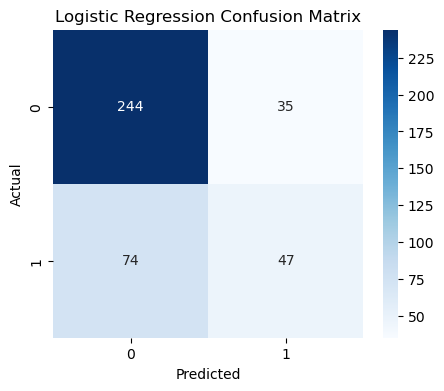


========== Random Forest ==========
Accuracy: 0.755
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       279
           1       0.62      0.50      0.55       121

    accuracy                           0.76       400
   macro avg       0.71      0.68      0.69       400
weighted avg       0.74      0.76      0.75       400



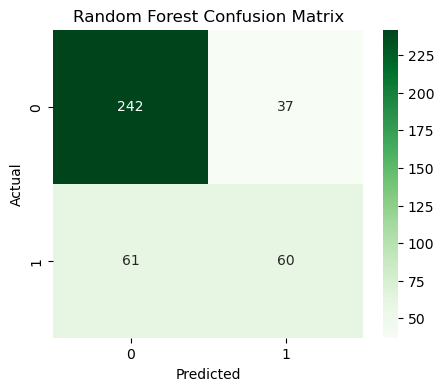


Top Important Features:
MonthlyCharges    0.255992
TotalCharges      0.198714
Tenure            0.197381
Age               0.148717
Contract          0.119362
PaymentMethod     0.049465
Gender            0.030369
dtype: float64


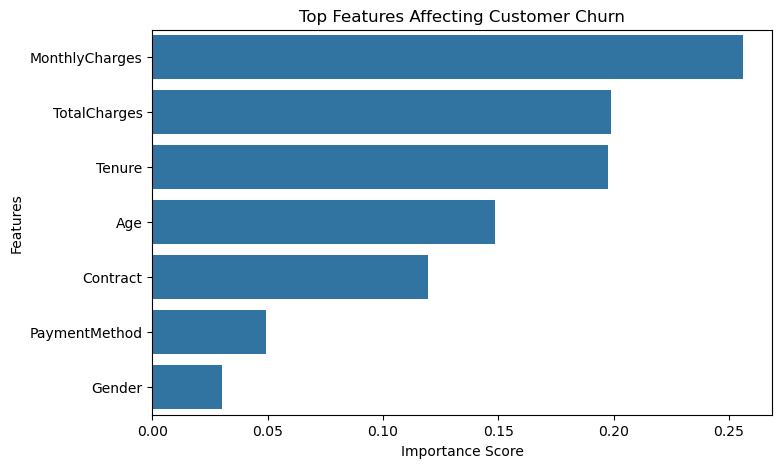


Customer Cluster Distribution:
Cluster
1    682
0    670
2    648
Name: count, dtype: int64


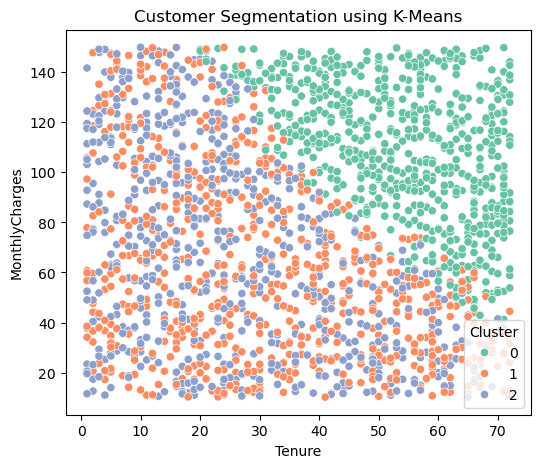


========== Chi-Square Test ==========
Feature Tested: Age
P-value: 0.31766025924761143
Result: No significant relationship with churn

Business Insight:
Customers with higher monthly charges and shorter tenure are more likely to churn.


In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "8"
# STEP 1 : Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans

from scipy.stats import chi2_contingency
from transformers import pipeline


# STEP 2: Load Dataset

df = pd.read_csv("Customer churn dataset.csv")
print("\nDataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

# STEP 3: Data Preprocessing
if "CustomerID" in df.columns:
    df.drop("CustomerID", axis=1, inplace=True)
encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = encoder.fit_transform(df[col])

print("\nData after encoding:")
print(df.head())



# STEP 4: Define Features & Target
X = df.drop("Churn", axis=1)
y = df["Churn"]



# STEP 5: Feature Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



# STEP 6: Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# STEP 7: Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("\n========== Logistic Regression ==========")
print("Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# STEP 8: Random Forest Model

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\n========== Random Forest ==========")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# STEP 9: Feature Importance
importances = rf_model.feature_importances_
feature_importance = pd.Series(importances, index=X.columns)
top_features = feature_importance.sort_values(ascending=False).head(10)

print("\nTop Important Features:")
print(top_features)

plt.figure(figsize=(8,5))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top Features Affecting Customer Churn")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()



# STEP 10:  K-Means

kmeans = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print("\nCustomer Cluster Distribution:")
print(df["Cluster"].value_counts())

plt.figure(figsize=(6,5))
sns.scatterplot(x=df["Tenure"], y=df["MonthlyCharges"], hue=df["Cluster"], palette="Set2")
plt.title("Customer Segmentation using K-Means")
plt.show()

# STEP 11: Chi-Square Hypothesis Testing

feature_to_test = X.columns[0]

contingency_table = pd.crosstab(df[feature_to_test], df["Churn"])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\n========== Chi-Square Test ==========")
print("Feature Tested:", feature_to_test)
print("P-value:", p)

if p < 0.05:
    print("Result: Significant relationship with churn")
else:
    print("Result: No significant relationship with churn")

# STEP 12: Business Insight Generator
print("\nBusiness Insight:")
print("Customers with higher monthly charges and shorter tenure are more likely to churn.")